# <span style="color:#00bfff">Unidad 4. Inteligencia Artificial Moderna</span>

## <span style="color:#00bfff">Redes Neuronales Artificiales RNA (ANN)</span>

Ejemplo de ANN con Keras sobre el dataset Iris. 

1. Instalación de la librería Tensorflow

In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Scripts\python.exe: No module named pip


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
import numpy as np

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)
# 2. Escalamiento de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. One-hot encoding para etiquetas
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42
)

# 5. Construcción del modelo ANN
model = Sequential(
    [
        Dense(
            10, activation="relu", input_shape=(X.shape[1],)
        ),  # 4 características de entrada
        Dense(8, activation="relu"),  # Capa oculta con 8 neuronas
        Dense(3, activation="softmax"),  # 3 clases
    ]
)

# 6. Compilar modelo
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 7. Entrenar modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

# 8. Evaluar modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en test: {acc:.3f}")

# 9. Predicciones y reporte
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(
    "\nReporte de clasificación:\n",
    classification_report(y_true_labels, y_pred_labels, target_names=iris.target_names),
)

Epoch 1/100


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3429 - loss: 1.3339  
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3333 - loss: 1.2537 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3905 - loss: 1.1822 
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5429 - loss: 1.1229 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6095 - loss: 1.0728 
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6095 - loss: 1.0260 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6095 - loss: 0.9840 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5905 - loss: 0.9468 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6095 - loss: 0.9105 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6190 - loss: 0.8747 
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6190 - loss: 0.8431 
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

Visualización del entrenamiento

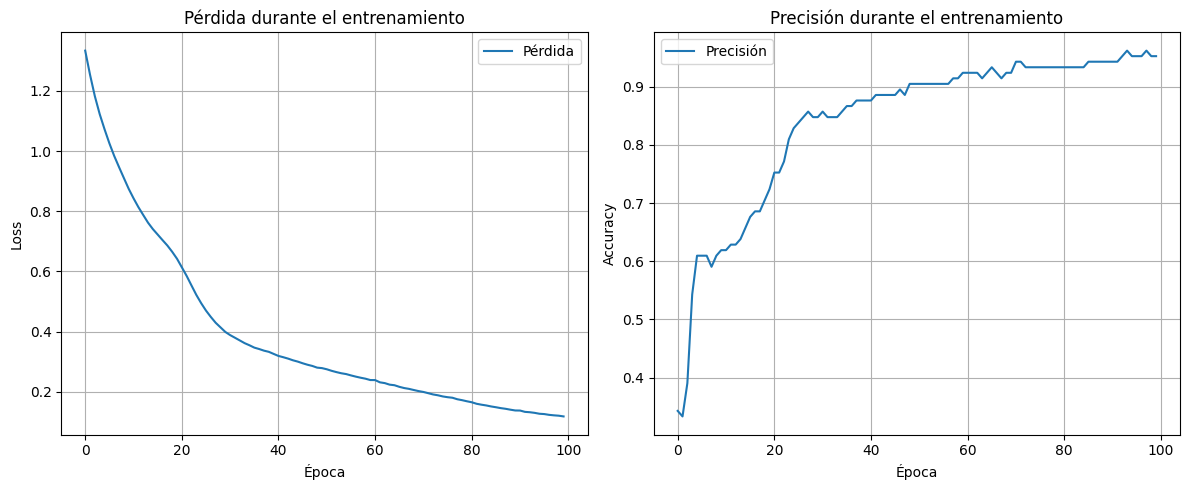

In [5]:
import matplotlib.pyplot as plt

# Visualizar evolución de la pérdida
plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Gráfico de la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Precisión")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Convolucionales - CNN</span>

A continuación, se construye y entrena una Red Neuronal Convolucional (CNN) con Keras usando el clásico dataset MNIST, que contiene imágenes en escala de grises de dígitos escritos a mano (0 al 9) en tamaño 28x28 píxeles.

1. Importación de librerías y carga de datos

In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Cargar dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar a [0,1] y expandir dimensiones (para CNN)
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0 
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Codificar las etiquetas (one-hot)
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10) 

2. Previsualización de datos cargados

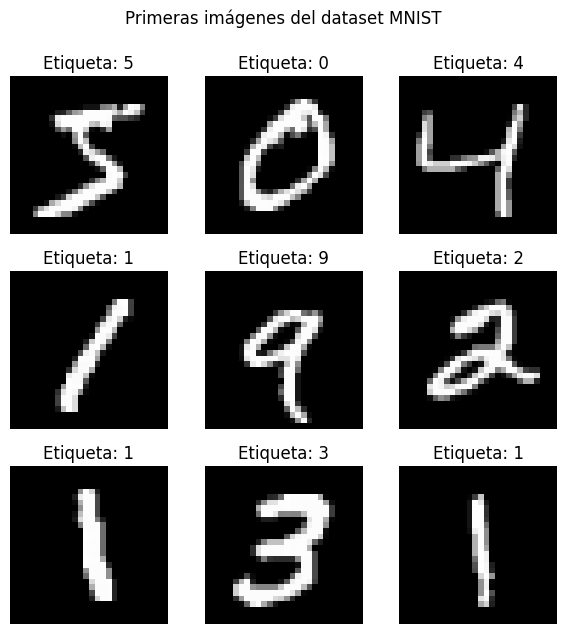

In [7]:
import matplotlib.pyplot as plt

# Mostrar las primeras 9 imágenes del conjunto de entrenamiento
plt.figure(figsize=(6, 6))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Primeras imágenes del dataset MNIST", y=1.05)
plt.show()

3. Construir el modelo CNN

In [8]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(), # Se aplana la salida de la última capa convolucional para conectarla a la capa densa
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Compilar y entrenar

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=5, batch_size=64) 

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9510 - loss: 0.1634 - val_accuracy: 0.9842 - val_loss: 0.0532
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9846 - loss: 0.0491 - val_accuracy: 0.9883 - val_loss: 0.0367
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9893 - val_loss: 0.0334
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9936 - loss: 0.0194 - val_accuracy: 0.9897 - val_loss: 0.0347


5. Evaluar y mostrar resultados

In [10]:
# Evaluación en test
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\nPrecisión en test: {acc:.4f}") 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0319

Precisión en test: 0.9899


6. Visualizar curvas de entrenamiento

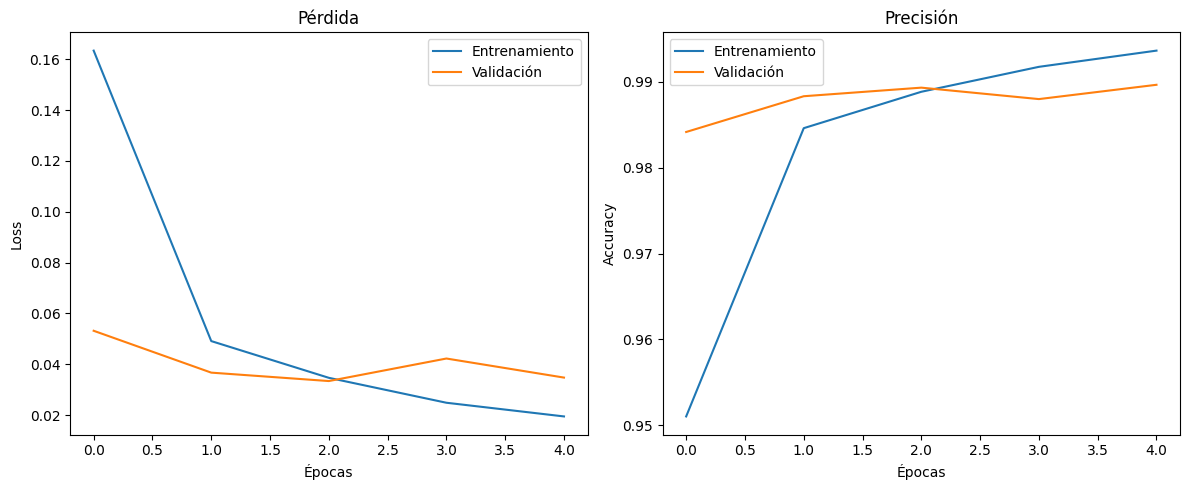

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Precisión
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Recurrentes - RNN</span>

1. Preparación de los datos

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generar serie senoidal
x = np.linspace(0, 100, 500)
serie = np.sin(x)

# Escalar entre 0 y 1
scaler = MinMaxScaler()
serie_norm = scaler.fit_transform(serie.reshape(-1, 1))

# Crear ventanas de entrada/salida
def crear_ventanas(data, pasos=10):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos])
    return np.array(X), np.array(y)

pasos = 20
X, y = crear_ventanas(serie_norm, pasos)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Requerido por LSTM

2. Construir y entrenar el modelo LSTM

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='tanh', input_shape=(pasos, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, batch_size=16, verbose=1)

Epoch 1/20


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1642  
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0574
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7114e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1149e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8107e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7702e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7139e-05
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6860e-05
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6401e-05
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3002e-05
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.5752e-06
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5528e-06
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2833e-06
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

3. Evaluar y visualizar resultados

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


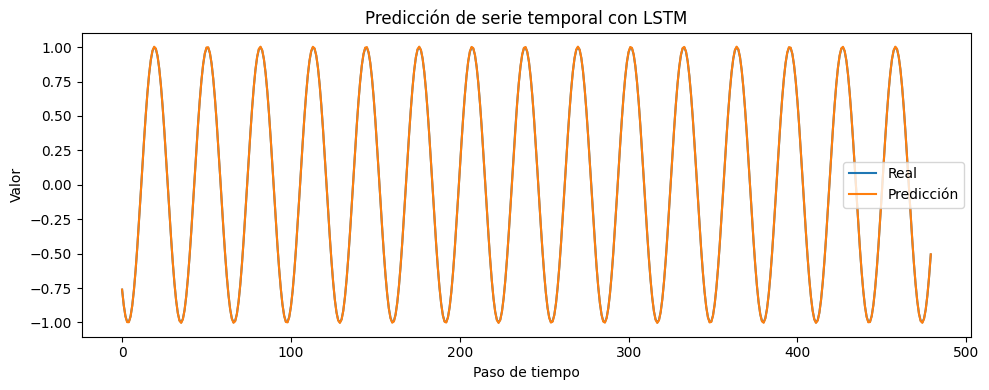

In [14]:
# Predecir con los mismos datos (ejemplo básico)
predicciones = model.predict(X)

# Invertir escalado
predicciones_inv = scaler.inverse_transform(predicciones)
y_real_inv = scaler.inverse_transform(y)

# Visualizar
plt.figure(figsize=(10,4))
plt.plot(y_real_inv, label='Real')
plt.plot(predicciones_inv, label='Predicción')
plt.title("Predicción de serie temporal con LSTM")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color:#00bfff">Ejemplo de prediccíón de datos de texto con LSTM</span>

1. Preparación del corpus del texto

In [15]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Texto base (puede ser más largo)
texto = """la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA está revolucionando industrias enteras, desde la medicina hasta el entretenimiento. 
        Con algoritmos avanzados y grandes volúmenes de datos, las máquinas están aprendiendo a 
        realizar tareas complejas que antes eran exclusivas de los humanos. Sin embargo, también 
        plantea desafíos éticos y sociales que deben ser abordados con responsabilidad y cuidado. 
        La IA no es solo una herramienta, sino un cambio de paradigma en nuestra forma de 
        interactuar con el mundo."""

# Crear vocabulario
caracteres = sorted(list(set(texto)))
char2idx = {c: i for i, c in enumerate(caracteres)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(caracteres)

# Convertir texto en secuencia de índices
secuencia = [char2idx[c] for c in texto]

# Crear pares entrada-salida
X = []
y = []
seq_length = 50

for i in range(len(secuencia) - seq_length):
    X.append(secuencia[i : i + seq_length])
    y.append(secuencia[i + seq_length])

X = np.array(X)
y = to_categorical(y, num_classes=vocab_size)

# Redimensionar para LSTM
X = X.reshape((X.shape[0], X.shape[1], 1)) / float(vocab_size)

2. Crear y entrenar el modelo LSTM

In [16]:
model = Sequential([
    #LSTM(128, input_shape=(X.shape[1], X.shape[2])),
    LSTM(256, input_shape=(seq_length, 1), return_sequences=True),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, batch_size=16, epochs=100, verbose=0)

c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3. Generar texto a partir de una semilla

In [17]:
# Elegir una semilla
semilla = "la inteligencia artificial transforma el mundo de "
entrada = [char2idx[c] for c in semilla]

# Generar caracteres
generado = semilla

for _ in range(60):
    sec = np.array(entrada[-seq_length:]).reshape(1, seq_length, 1) / float(vocab_size)
    pred = model.predict(sec, verbose=0)
    index = np.argmax(pred)
    generado += idx2char[index]
    entrada.append(index)

print("Texto generado:\n", generado) 

Texto generado:
 la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA notá revolucionan


## <span style="color:#00bfff">Transformers</span>

1. Instalación de HuggingFace Transformers

In [18]:
%pip install transformers 

Note: you may need to restart the kernel to use updated packages.


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Scripts\python.exe: No module named pip


2. Cargar GPT-2 de HugginFace y generar texto. 

In [1]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# 1. Cargar el modelo preentrenado y el tokenizer
modelo = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# 2. Frase inicial
semilla = "Artificial intelligence will transform the world in the following ways:"

# 3. Codificar entrada
input_ids = tokenizer.encode(semilla, return_tensors="pt")

# 4. Generar texto
output = modelo.generate(
    input_ids,
    max_length=100,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    temperature=0.6,
    top_k=50,
    top_p=0.95,
    do_sample=True
)

# 5. Decodificar y mostrar resultado
texto_generado = tokenizer.decode(output[0], skip_special_tokens=True)
print("\nTexto generado:\n")
print(texto_generado)

c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 4\u4\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sebas\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python 


Texto generado:

Artificial intelligence will transform the world in the following ways:

1. It will revolutionize the way we understand and use technology.
, The first step in this transformation is the creation of a new kind of artificial intelligence. We will be able to understand, interact with, and interact in ways that are not possible with human intelligence alone. This new approach will have a lot of implications for the future of society. As the technology advances, the ability to interact will become more and more important
